In [2]:
import os,sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
from matplotlib import colors, cm
import seaborn as sns
from scipy.stats import bootstrap
from matplotlib.cm import ScalarMappable
import matplotlib.lines as mlines
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import LineString, MultiLineString

In [3]:
module_path = "../src"
sys.path.append(os.path.abspath(module_path))
from results_analysis_rm import *

In [4]:
# INPUT PARAMETERS
removal_fraction = 0.05 # Options: 0.02 and 0.05
base_dir = "../outputs/20250729_0_0.3_31_1000"
# base_dir = "../outputs/20250729_0_0.3_7_10"
# net_dir = f"../figures/20250618_frac_{int(removal_fraction*100)}"

output_dir = "../figures/20250729_0_0.3_31_1000"
# output_dir = "../figures/overload_analysis_250729"
os.makedirs(output_dir, exist_ok=True)

In [5]:
lines_gdf = gpd.read_file('../outputs/table_lines_200m_update_remove_disconnected.gpkg')
nodes_gdf = gpd.read_file('../outputs/table_nodes_200m_update_remove_disconnected.gpkg')
loads_gdf = gpd.read_file('../outputs/landuse_sites_gdf_add_bus.gpkg')
basemap = gpd.read_file("../data/base_map/vnm_admbnda_adm1_gov_20201027.shp")

overload_lines_df = pd.read_csv(f"{base_dir}/overloaded_lines_records.csv")
failed_lines_df = pd.read_csv(f"{base_dir}/failed_lines_records.csv")
failed_nodes_df = pd.read_csv(f"{base_dir}/failed_buses_records.csv")
load_ratio_df = pd.read_csv(f"{base_dir}/load_served_ratio.csv")
load_status_df = pd.read_csv(f"{base_dir}/load_status_records.csv")
results_df = pd.read_csv(f"{base_dir}/percolation_overall_results.csv")
# percolation_result_csv=(f"{base_dir}/percolation_overall_results.csv")

C:\Users\mye500\AppData\Local\Temp\ipykernel_30008\1294487758.py:9: DtypeWarning: Columns (5,6,7,8,9,10,11,12,13,14,16,17,23,24,27,29,30,34,38,41,49,53,58,63,68,69,72,73,80,86,87,90,91,95,118,126,127,130,142,162,163,168,170,173,180,206,210,213,214,243,245,252,336,339,340,341,353,355,357,358,359,360,371,372,373,374,375,376,377,378) have mixed types. Specify dtype option on import or set low_memory=False.
  load_ratio_df = pd.read_csv(f"{base_dir}/load_served_ratio.csv")


In [6]:
nodes_gdf, lines_gdf, loads_gdf = assign_adm1_codes_with_ref_and_pcode(nodes_gdf, lines_gdf, loads_gdf, basemap)

In [ ]:
# Calculate failure frequency at 0.05
iter_lines = failed_lines_df[np.isclose(failed_lines_df["removal_fraction"], 0.05)]
iter_nodes = failed_nodes_df[np.isclose(failed_nodes_df["removal_fraction"], 0.05)]
num_iter = iter_lines["iteration"].nunique()

lines_gdf["fail_prob_0_05"] = lines_gdf["LineID"].map(iter_lines["name"].value_counts() / num_iter).fillna(0)
nodes_gdf["fail_prob_0_05"] = nodes_gdf["NodeID"].map(iter_nodes["name"].value_counts() / num_iter).fillna(0)

In [96]:
# Calculate failure frequency at all removal fractions
# --- 获取所有 removal_fraction 的唯一值 ---
removal_fractions = sorted(failed_lines_df["removal_fraction"].unique())

for frac in removal_fractions:
    # 筛选当前 removal_fraction 下的失败记录
    iter_lines = failed_lines_df[np.isclose(failed_lines_df["removal_fraction"], frac)]
    iter_nodes = failed_nodes_df[np.isclose(failed_nodes_df["removal_fraction"], frac)]
    
    # 当前 removal_fraction 下的模拟次数
    num_iter = iter_lines["iteration"].nunique()

    # 计算 failure probability
    fail_prob_lines = iter_lines["name"].value_counts() / num_iter
    fail_prob_nodes = iter_nodes["name"].value_counts() / num_iter

    # 添加到 gdf 中的新列名
    col_line = f"fail_prob_{str(frac).replace('.', '_')}"
    col_node = f"fail_prob_{str(frac).replace('.', '_')}"

    lines_gdf[col_line] = lines_gdf["LineID"].map(fail_prob_lines).fillna(0)
    nodes_gdf[col_node] = nodes_gdf["NodeID"].map(fail_prob_nodes).fillna(0)

In [97]:
nodes_gdf.head()

,NodeID,voltage,lon,lat,OriginalID,line_counts,sn_mva,disconnected,geometry,ADM1_EN,...,fail_prob_0_21,fail_prob_0_22,fail_prob_0_23,fail_prob_0_24,fail_prob_0_25,fail_prob_0_26,fail_prob_0_27,fail_prob_0_28,fail_prob_0_29,fail_prob_0_3
0,NODEVN3270a,110.0,610714.852695,2.315181e+06,153608703.0,4.0,731.618261,no,POINT (610714.853 2315180.7),Hung Yen,...,0.211,0.245,0.230,0.263,0.234,0.261,0.265,0.287,0.301,0.294
1,NODEVN0003a,220.0,682154.017051,2.315888e+06,4.0,6.0,2194.854783,no,POINT (682154.017 2315887.79),Hai Phong city,...,0.217,0.224,0.225,0.253,0.291,0.254,0.280,0.276,0.311,0.299
2,NODEVN3273a,110.0,684889.726446,2.304274e+06,241065371.0,3.0,548.713696,no,POINT (684889.726 2304273.827),Hai Phong city,...,0.205,0.229,0.206,0.246,0.231,0.256,0.266,0.268,0.293,0.295
3,NODEVN3273b,220.0,684710.914392,2.304283e+06,241065371.0,4.0,1463.236522,no,POINT (684710.914 2304282.784),Hai Phong city,...,0.215,0.210,0.261,0.240,0.241,0.253,0.292,0.280,0.289,0.302
4,NODEVN3308,220.0,810022.256590,1.417833e+06,400413519.0,2.0,731.618261,no,POINT (810022.257 1417832.602),Dak Lak,...,0.203,0.217,0.257,0.232,0.240,0.253,0.270,0.281,0.277,0.304


In [ ]:
# lines_gdf = lines_gdf.drop(columns=["overload_count", "overload_prob","overload_count_0_05_y", "overload_prob_0_05_y"], errors="ignore")

In [79]:
# Merge overload ratio stats
# 仅选取 removal_fraction 为 0.05 的模拟结果
overload_lines_df_0_05 = overload_lines_df[np.isclose(overload_lines_df["removal_fraction"], 0.05)]

overload_count_0_05 = overload_lines_df_0_05.groupby("line_name").size().rename("overload_count_0_05").reset_index()
# 真实参与仿真的总次数（成功且线路有结果）
sim_combinations_0_05 = overload_lines_df_0_05[["removal_fraction", "iteration"]].drop_duplicates()
num_simulations_0_05 = sim_combinations_0_05.shape[0]

overload_count_0_05["overload_prob_0_05"] = overload_count_0_05["overload_count_0_05"] / num_simulations_0_05
overload_count_0_05 = overload_count_0_05.sort_values("overload_prob_0_05", ascending=False)
overload_count_0_05.to_csv(os.path.join(output_dir, "overloaded_line_stats_frac_0.05.csv"))

lines_gdf = lines_gdf.merge(overload_count_0_05.rename(columns={"line_name": "LineID"}), on="LineID", how="left")
lines_gdf["overload_prob_0_05"] = lines_gdf["overload_prob_0_05"].fillna(0)

In [93]:
# 选取所有 removal_fraction 为模拟结果
# 统计每条线路超载次数
overload_count = overload_lines_df.groupby("line_name").size().rename("overload_count").reset_index()
# 真实参与仿真的总次数（成功且线路有结果）
sim_combinations = overload_lines_df[["removal_fraction", "iteration"]].drop_duplicates()
num_simulations = sim_combinations.shape[0]

overload_count["overload_prob"] = overload_count["overload_count"] / num_simulations
overload_count = overload_count.sort_values("overload_prob", ascending=False)
overload_count.to_csv(os.path.join(output_dir, "overloaded_line_stats_frac.csv"))

lines_gdf = lines_gdf.merge(overload_count.rename(columns={"line_name": "LineID"}), on="LineID", how="left")
lines_gdf["overload_prob"] = lines_gdf["overload_prob"].fillna(0)

Run all analysis modules

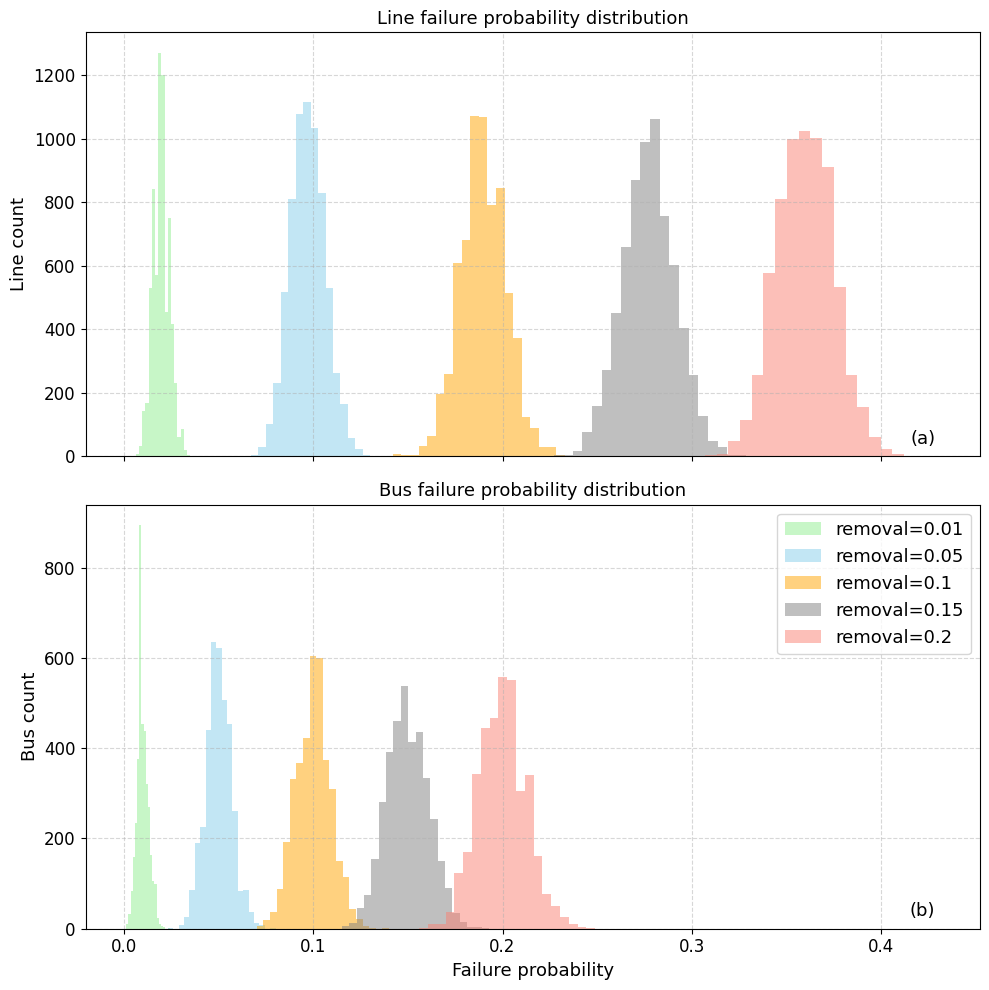

In [9]:
plot_failure_frequency_histograms(failed_lines_df, failed_nodes_df, output_dir)

nodes_zero: 0 0
nodes_nonzero: 3692 0
lines_zero: 1 0
lines_nonzero: 6798 0
nodes_highlight: 231
lines_highlight: 368


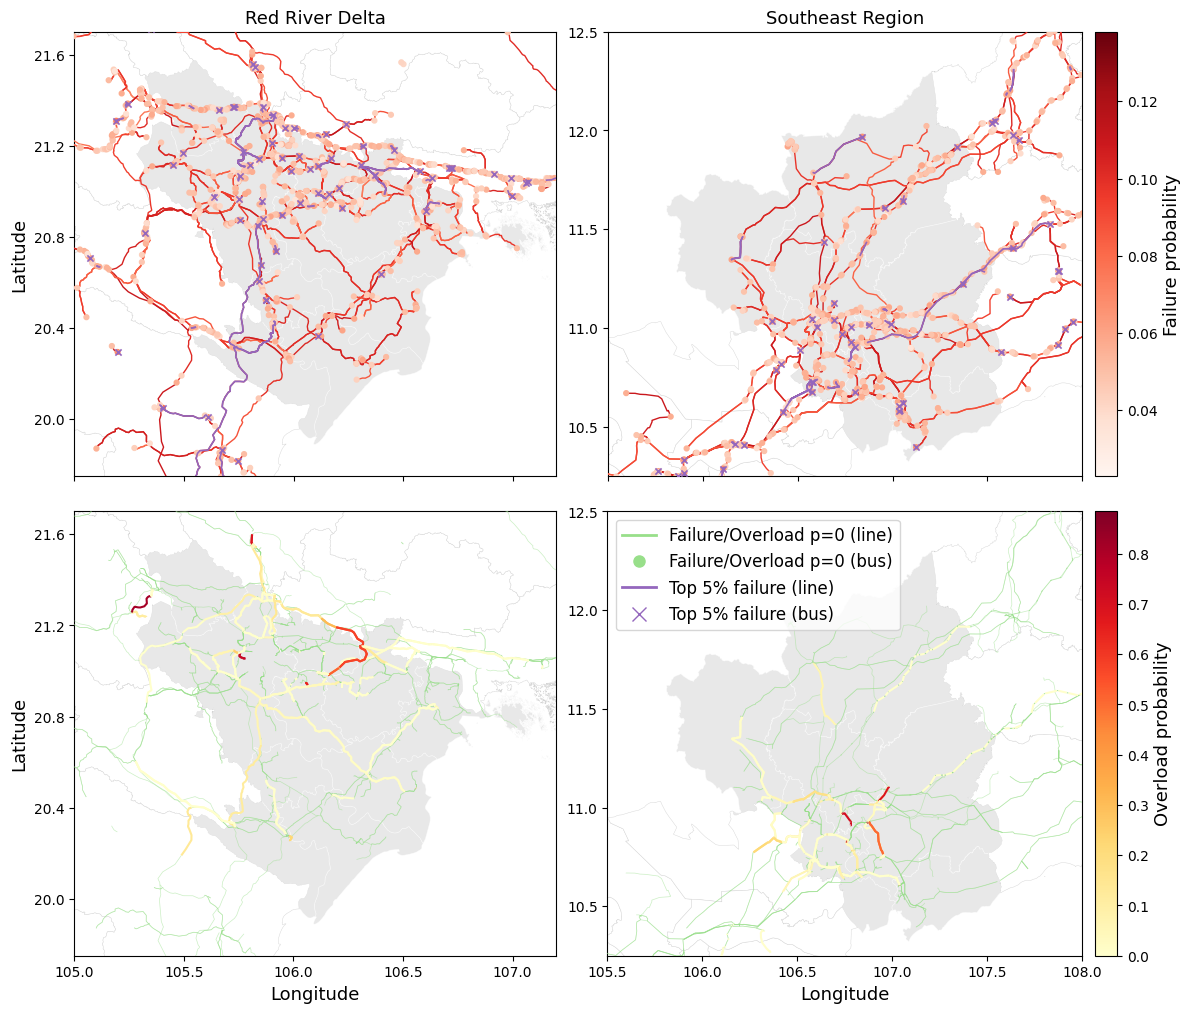

In [82]:
combine_failure_and_overload_maps(lines_gdf, nodes_gdf, basemap, output_dir)

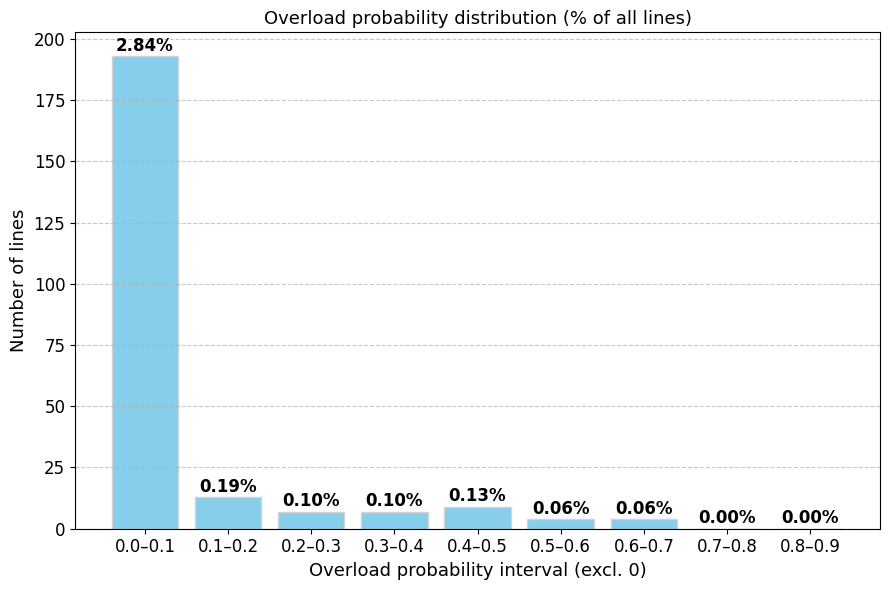

In [95]:
# This result is based on all removal fractions
plot_overload_histogram(lines_gdf, output_dir, basemap)

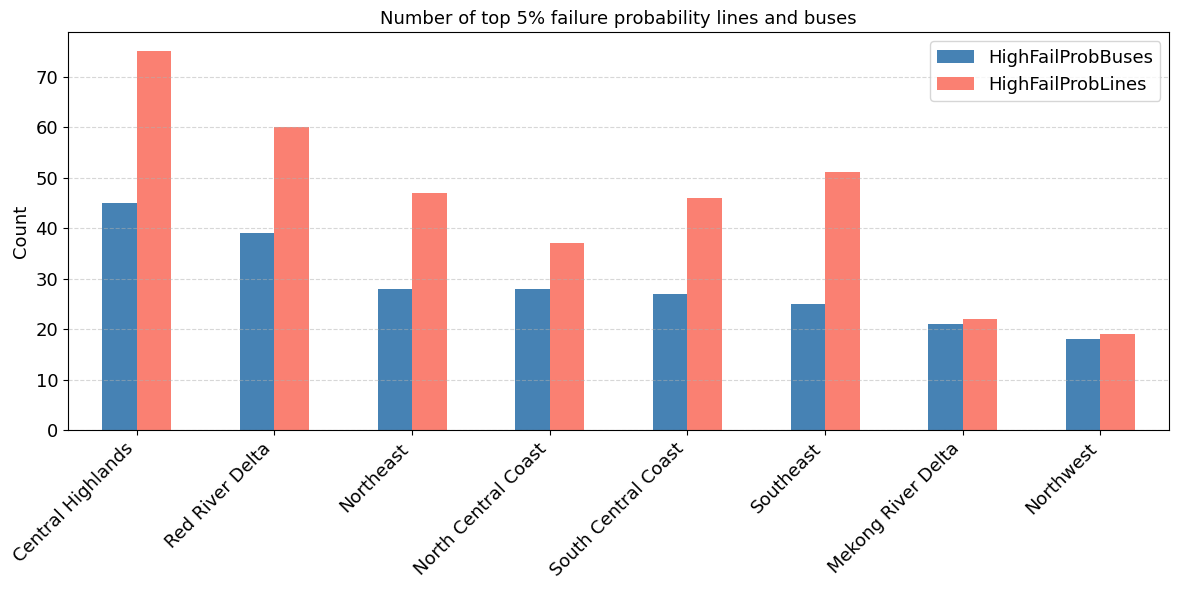

In [99]:
summarize_top_failure_adm_regions(nodes_gdf, lines_gdf, output_dir)

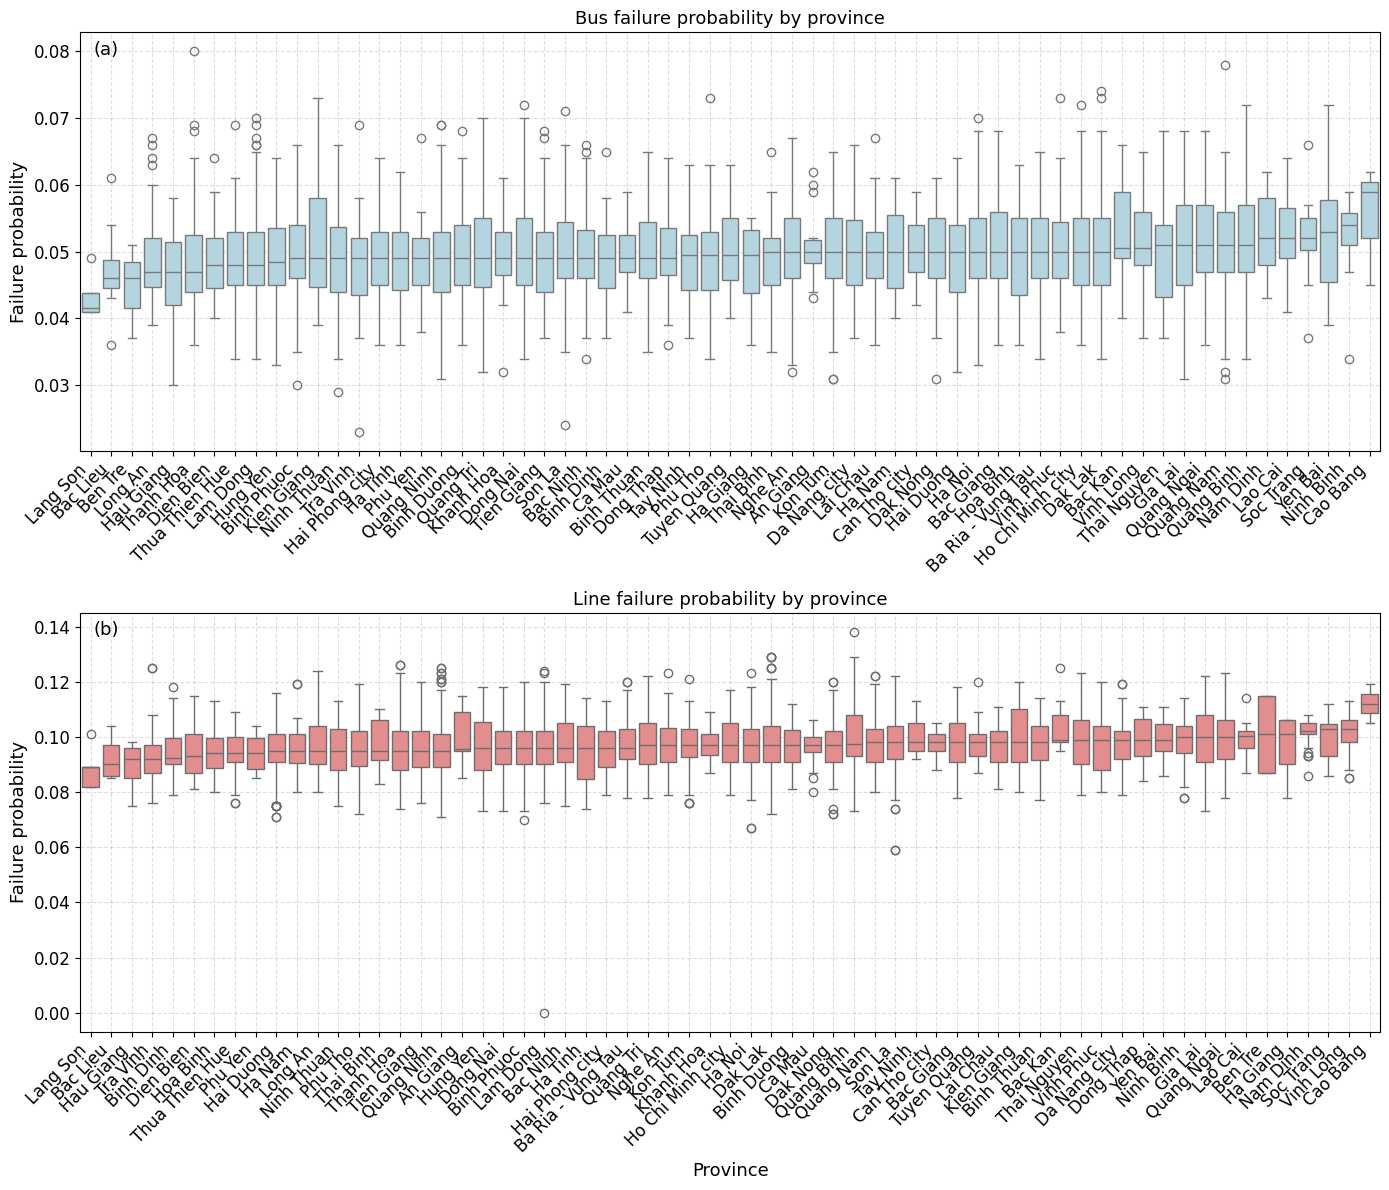

In [13]:
analyze_failure_distribution_by_adm(nodes_gdf, lines_gdf, output_dir)

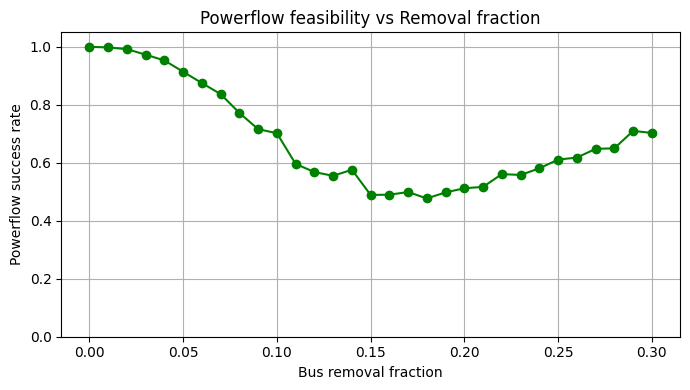

In [14]:
analyze_powerflow_success(results_df, output_dir)

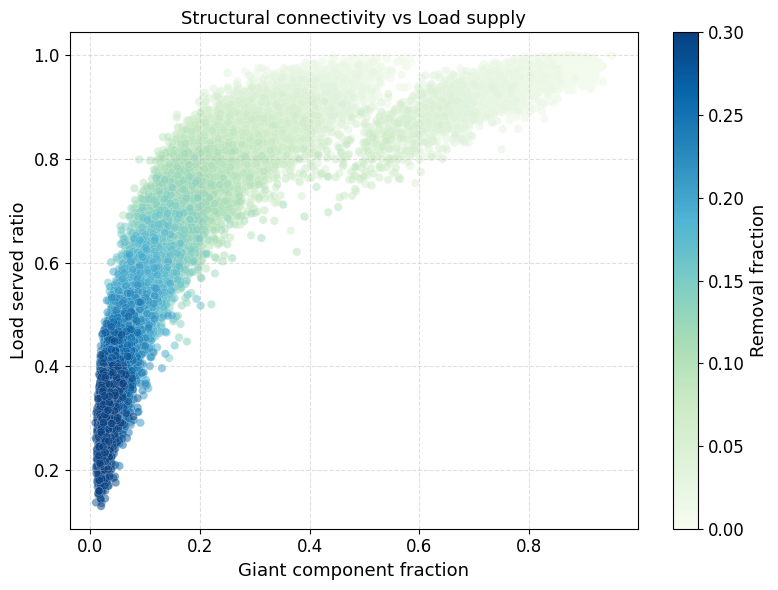

In [15]:
analyze_connectivity_vs_supply(results_df, output_dir)

In [ ]:
def analyze_load_served_ratio_by_adm(load_ratio_df, loads_gdf, output_dir):
    df = load_ratio_df[np.isclose(load_ratio_df["removal_fraction"], 0.05, atol=1e-5)]
    avg_served = df.groupby("osmid")["served_ratio_mean"].mean().rename("served_ratio")
    loads_gdf = loads_gdf.copy()
    loads_gdf["served_ratio"] = loads_gdf["osmid"].map(avg_served)
    filtered = loads_gdf.dropna(subset=["ADM1_EN", "served_ratio"])

    median_order = (
        filtered.groupby("ADM1_EN")["served_ratio"]
        .median()
        .sort_values(ascending=True)
        .reset_index()
        .rename(columns={"served_ratio": "served_ratio_median"})
    )
    median_order_list = median_order["ADM1_EN"].astype(str).tolist()
    counts = filtered["ADM1_EN"].value_counts().reindex(median_order_list).fillna(0)

    # Calculate standard deviation per ADM1_EN
    std_dev = filtered.groupby("ADM1_EN")["served_ratio"].std().reset_index(name="served_ratio_std")
    merged_stats = pd.merge(median_order, std_dev, on="ADM1_EN")

    # Identify top 5 unstable and stable provinces
    df_unstable = merged_stats.sort_values(by="served_ratio_std", ascending=False).head(5)
    df_stable = merged_stats.sort_values(by="served_ratio_std", ascending=True).head(5)
    fig, ax1 = plt.subplots(figsize=(14, 6))

    # Boxplot
    sns.boxplot(
        data=filtered,
        x="ADM1_EN",
        y="served_ratio",
        order=median_order_list,
        ax=ax1,
        color="skyblue"
    )

    # 均值 + CI
    # means = filtered.groupby("ADM1_EN")["served_ratio"].mean()
    # for xtick, adm1 in enumerate(median_order_list):
    #     group = filtered[filtered["ADM1_EN"] == adm1]["served_ratio"].values
    #     if len(group) > 1:
    #         ci = bootstrap((group,), np.mean, confidence_level=0.95, n_resamples=1000, method="basic")
    #         ci_low, ci_high = ci.confidence_interval
    #         ax1.plot(xtick, means[adm1], 'ro')  # mean
    #         ax1.vlines(xtick, ci_low, ci_high, color='#8C564B', linewidth=1.2)
    #     else:
    #         ax1.plot(xtick, means[adm1], 'ro')

    # 平均线
    # ax1.axhline(filtered["served_ratio"].mean(), color="green", linestyle="--", linewidth=1.2, label="Global Mean")
    ax1.set_ylabel("Served ratio", fontsize=13)
    ax1.set_xlabel("Provinces (sorted by median served ratio)", fontsize=13)
    ax1.set_xticklabels(median_order_list, rotation=45, ha="right")
    ax1.tick_params(axis='x', labelsize=10)
    ax1.grid(axis="y", linestyle="--", alpha=0.4)

    # Color xtick labels for stable/unstable
    xtick_labels = ax1.get_xticklabels()
    for label in xtick_labels:
        adm = label.get_text()
        if adm in df_unstable["ADM1_EN"].values:
            label.set_fontweight("bold")
        elif adm in df_stable["ADM1_EN"].values:
            label.set_color("#2CA02C")  # green

    # === 右侧 y 轴 ===
    ax2 = ax1.twinx()
    ax2.bar(median_order_list, counts.values, alpha=0.25, color="gray", label="Load count")
    ax2.set_ylabel("Load count", fontsize=13)
    # ax2.legend(loc="upper right", fontsize=13)
    ax2.legend(loc='center right', bbox_to_anchor=(1, 0.25), fontsize=13)

    plt.title("Loads served ratio distribution and load count by province (removal_fraction = 0.05)", fontsize=13)
    plt.tight_layout()
    # os.makedirs(output_dir, exist_ok=True)
    plt.savefig(os.path.join(output_dir, "load_served_ratio_boxplot_by_adm1_count.png"), dpi=400)

    return filtered, median_order, std_dev, df_unstable, df_stable

C:\Users\mye500\AppData\Local\Temp\ipykernel_30008\2060259921.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(median_order_list, rotation=45, ha="right")


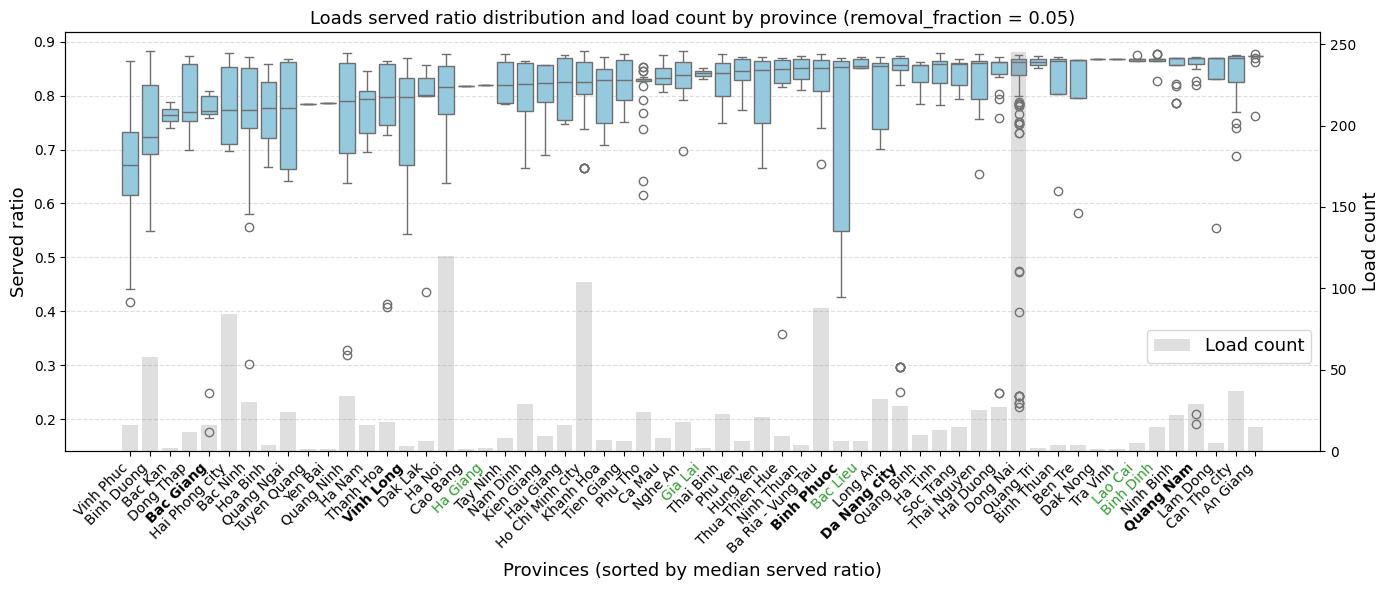

In [141]:
loads_gdf_filtered, median_order, std_dev, df_unstable, df_stable = analyze_load_served_ratio_by_adm(load_ratio_df, loads_gdf, output_dir)

In [130]:
median_order

,ADM1_EN,served_ratio_median
0,Vinh Phuc,0.6720
1,Binh Duong,0.7235
2,Bac Kan,0.7640
3,Dong Thap,0.7690
4,Bac Giang,0.7720
5,Hai Phong city,0.7725
6,Bac Ninh,0.7740
7,Hoa Binh,0.7765
8,Quang Ngai,0.7770
9,Tuyen Quang,0.7850


In [142]:
df_unstable

,ADM1_EN,served_ratio_median,served_ratio_std
39,Da Nang city,0.857,0.240377
36,Binh Phuoc,0.853,0.219044
4,Bac Giang,0.772,0.196762
54,Quang Nam,0.869,0.171515
14,Vinh Long,0.797,0.171082


In [143]:
df_stable

,ADM1_EN,served_ratio_median,served_ratio_std
18,Ha Giang,0.820,0.000000
51,Lao Cai,0.867,0.004583
37,Bac Lieu,0.854,0.010159
52,Binh Dinh,0.867,0.011641
29,Gia Lai,0.841,0.015556


In [ ]:
# def analyze_load_served_ratio_by_adm(loads_gdf, load_status_df, results_df, output_dir, removal_fraction=0.05):
#     # === Step 1: 读取成功迭代 ===
#     passed_iters = (
#         results_df[
#             (results_df["powerflow_success"] == True) &
#             (results_df["removal_fraction"] == removal_fraction)
#         ]["iteration"]
#         .astype(int)
#         .squeeze()
#         .tolist()
#     )
#     print(f"\u2713 Found {len(passed_iters)} successful iterations")

#     all_records = []

#     for i in passed_iters:
#         filepath = os.path.join(output_dir, f"net_results_frac_{int(removal_fraction * 100)}_fail_iter{i+1}.xlsx")
#         try:
#             xls = pd.read_excel(filepath, sheet_name=None)
#             df_load = xls["load"]
#             df_res = xls["res_load"]
#         except Exception as e:
#             print(f"\u2717 Skipping {filepath}: {e}")
#             continue

#         df = df_load[["name", "p_mw"]].merge(
#             df_res[["p_mw"]], left_index=True, right_index=True, suffixes=("", "_res")
#         ).rename(columns={"name": "load_id", "p_mw": "p_mw", "p_mw_res": "res_p_mw"})

#         id_adm_df = loads_gdf[["osmid", "ADM1_EN"]].rename(columns={"osmid": "load_id"})
#         df = pd.merge(df, id_adm_df, on="load_id", how="left").dropna(subset=["ADM1_EN"])

#         grouped = df.groupby("ADM1_EN")[["res_p_mw", "p_mw"]].sum()
#         grouped["served_ratio"] = grouped["res_p_mw"] / grouped["p_mw"]
#         grouped["iteration"] = i
#         all_records.append(grouped.reset_index()[["ADM1_EN", "iteration", "served_ratio"]])

#     df_all = pd.concat(all_records, ignore_index=True)
#     df_std = df_all.groupby("ADM1_EN")["served_ratio"].std().reset_index(name="served_ratio_std")
#     df_min = df_all.groupby("ADM1_EN")["served_ratio"].min().reset_index(name="served_ratio_min")

#     # Unstable (high std)
#     df_unstable = df_std.merge(df_min, on="ADM1_EN")
#     df_unstable = df_unstable.sort_values(by="served_ratio_std", ascending=False).head(5)
#     print("\nTop 5 unstable provinces (by std of served_ratio):")
#     print(df_unstable)

#     # Stable (low std)
#     df_stable = df_std.merge(df_min, on="ADM1_EN")
#     df_stable = df_stable.sort_values(by="served_ratio_std", ascending=True).head(5)
#     print("\nTop 5 stable provinces (by std of served_ratio):")
#     print(df_stable)

#     # === Step 3: Prepare average failed ratio per region ===
#     id_adm_df = loads_gdf[['osmid', 'ADM1_EN']].rename(columns={'osmid': 'load_id'})
#     status_with_adm = pd.merge(load_status_df, id_adm_df, on='load_id', how='left')
#     status_with_adm['served'] = status_with_adm['served'].astype(bool)
#     status_with_adm = status_with_adm[status_with_adm['iteration'].isin(passed_iters)]

#     failure_ratio = (
#         status_with_adm
#         .groupby(['iteration', 'ADM1_EN'])['served']
#         .apply(lambda x: (~x).sum() / len(x))
#         .reset_index(name='failed_ratio')
#     )

#     avg_failed_ratio = (
#         failure_ratio
#         .groupby('ADM1_EN')['failed_ratio']
#         .mean()
#         .fillna(0)
#     )

#     # Filter provinces with failure
#     adm_with_failures = failure_ratio[failure_ratio["failed_ratio"] > 0]["ADM1_EN"].unique()
#     df_all = df_all[df_all["ADM1_EN"].isin(adm_with_failures)]
#     avg_failed_ratio = avg_failed_ratio.loc[adm_with_failures]

#     df_avg = df_all.groupby("ADM1_EN")["served_ratio"].mean().reset_index(name="served_ratio_mean")

#     # Sort order by median served_ratio
#     df_median = df_all.groupby("ADM1_EN")["served_ratio"].median().reset_index(name="served_ratio_median")
#     sort_order = df_median.sort_values("served_ratio_median")["ADM1_EN"]

#     # === Step 4: 绘图 ===
#     fig, ax1 = plt.subplots(figsize=(16, 8))

#     # sns.boxplot(
#     #     data=df_all,
#     #     x="ADM1_EN",
#     #     y="served_ratio",
#     #     order=sort_order,
#     #     ax=ax1,
#     #     color="skyblue"
#     # )

#     means = df_all.groupby("ADM1_EN")["served_ratio"].mean()

#     for xtick, adm1 in enumerate(sort_order):
#         group = df_all[df_all["ADM1_EN"] == adm1]["served_ratio"].values
#         if len(group) > 1:
#             ci = bootstrap((group,), np.mean, confidence_level=0.95, n_resamples=1000, method="basic")
#             ci_low, ci_high = ci.confidence_interval
#             # ax1.plot(xtick, means[adm1], 'ro')
#             # ax1.vlines(xtick, ci_low, ci_high, color='black', linewidth=1.2)
#         # else:
#         #     ax1.plot(xtick, means[adm1], 'ro')

#     # 设置 x tick label 颜色（红色为最不稳定，绿色为最稳定）
#     xtick_labels = ax1.get_xticklabels()
#     for label in xtick_labels:
#         adm = label.get_text()
#         if adm in df_unstable["ADM1_EN"].values:
#             label.set_color("#D62728")
#         elif adm in df_stable["ADM1_EN"].values:
#             label.set_color("#2CA02C")

#     ax1.set_ylabel("Served ratio", fontsize=14)
#     ax1.set_xlabel("Province (sorted by median served ratio)", fontsize=14)
#     ax1.set_xticklabels(xtick_labels, rotation=45, ha="right")
#     ax1.grid(axis="y", linestyle="--", alpha=0.4)
#     ax1.tick_params(axis='both', labelsize=13)

#     # Right Y-axis: avg failed ratio
#     # ax2 = ax1.twinx()
#     # ax2.bar(sort_order, avg_failed_ratio.loc[sort_order].values, alpha=0.25, color="gray", label="Average failed ratio")
#     # ax2.set_ylabel("Average failed load ratio", fontsize=14)
#     # ax2.legend(loc="lower right", fontsize=14)
#     # ax2.tick_params(axis='both', labelsize=13)

#     plt.tight_layout()
#     os.makedirs(output_dir, exist_ok=True)
#     plt.savefig(os.path.join(output_dir, "load_served_ratio_boxplot_by_adm1.png"), dpi=600, bbox_inches='tight')
#     plt.show()

#     return df_all, df_median, df_std, df_avg, failure_ratio, avg_failed_ratio


✓ Found 914 successful iterations
✗ Skipping ../figures/20250729_0_0.3_31_1000\net_results_frac_5_fail_iter89.xlsx: [Errno 2] No such file or directory: '../figures/20250729_0_0.3_31_1000\\net_results_frac_5_fail_iter89.xlsx'
✗ Skipping ../figures/20250729_0_0.3_31_1000\net_results_frac_5_fail_iter90.xlsx: [Errno 2] No such file or directory: '../figures/20250729_0_0.3_31_1000\\net_results_frac_5_fail_iter90.xlsx'
✗ Skipping ../figures/20250729_0_0.3_31_1000\net_results_frac_5_fail_iter91.xlsx: [Errno 2] No such file or directory: '../figures/20250729_0_0.3_31_1000\\net_results_frac_5_fail_iter91.xlsx'
✗ Skipping ../figures/20250729_0_0.3_31_1000\net_results_frac_5_fail_iter92.xlsx: [Errno 2] No such file or directory: '../figures/20250729_0_0.3_31_1000\\net_results_frac_5_fail_iter92.xlsx'
✗ Skipping ../figures/20250729_0_0.3_31_1000\net_results_frac_5_fail_iter93.xlsx: [Errno 2] No such file or directory: '../figures/20250729_0_0.3_31_1000\\net_results_frac_5_fail_iter93.xlsx'
✗ Skip

C:\Users\mye500\AppData\Local\Temp\ipykernel_30008\1377260765.py:120: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(xtick_labels, rotation=45, ha="right")


FileNotFoundError: [WinError 53] The network path was not found: '../figures'

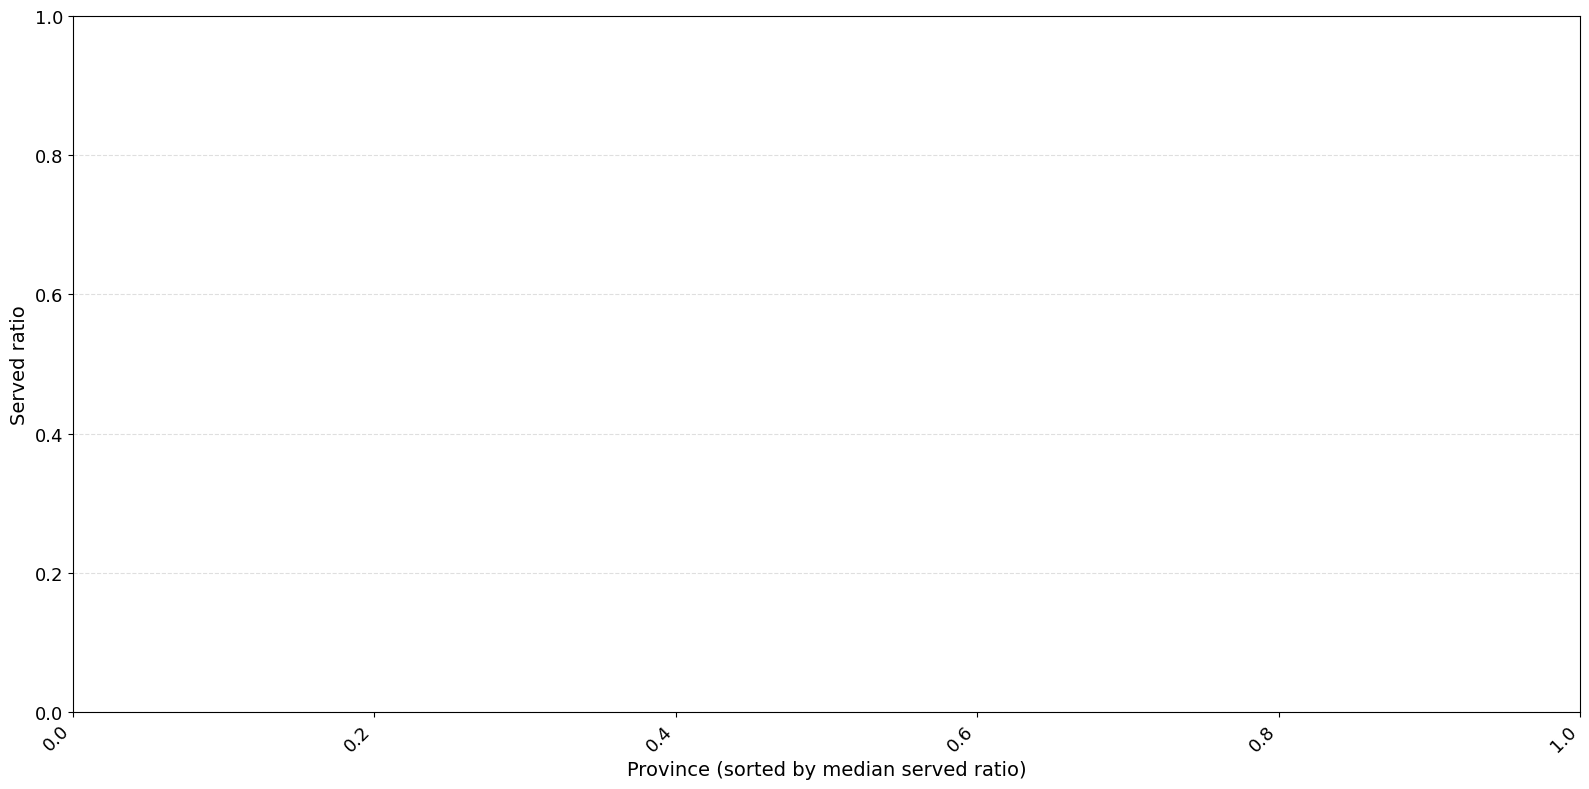

In [ ]:
# df_all, df_median, df_std, df_avg, failure_ratio, avg_failed_ratio = analyze_load_served_ratio_by_adm(
#     loads_gdf=loads_gdf,
#     load_status_df=load_status_df,
#     results_df=results_df,
#     output_dir=output_dir
# )

In [30]:
summary_df = export_summary_table(
    df_median=df_median, 
    df_std=df_std,
    df_avg=df_avg,
    avg_failed_ratio=avg_failed_ratio,
    loads_gdf=loads_gdf,
    output_dir=base_dir
)

In [ ]:
summary_df

,ADM1_EN,served_ratio_median,served_ratio_std,served_ratio_mean,avg_failed_ratio,number of loads
55,Vinh Long,0.835773,0.298941,72.3,59.8,3
2,Bac Giang,0.777336,0.221155,73.9,61.6,16
56,Vinh Phuc,0.895898,0.282936,75.9,70.0,16
8,Binh Duong,0.820312,0.189472,78.0,63.7,58
28,Hoa Binh,0.918441,0.244004,79.9,64.0,4
14,Da Nang city,0.783876,0.166081,80.1,56.6,28
50,Thanh Hoa,0.854383,0.203626,80.8,56.0,18
43,Quang Ngai,0.990237,0.251438,81.5,55.3,24
5,Bac Ninh,0.862510,0.200694,81.6,64.7,30
32,Lam Dong,0.998313,0.219576,82.8,50.8,5


10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"_pydevd_bundle.pydevd_constants.Null\"}]\n","stderr":"","mime":[]}
00{"name":"Exception","message":"not_supported","stack":["Traceback \u001b(most recent call last)\u001b:\n","\u001b  File \u001b<string>:174\u001b in \u001b__DW_DEBUG_WRAPPER__\u001b\n","\u001b  File \u001b<string>:165\u001b in \u001b__DW_GET_EXPRESSION_VARIABLE__\u001b\n","\u001bException\u001b\u001b:\u001b not_supported\n"]}
10{"stdout":"[{\"variableName\": \"ID_TO_MEANING\", \"type\": \"dictionary\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\": \"builtins.dict\"}, {\"variableName\": \"NULL\", \"type\": \"unknown\", \"supportedEngines\": [\"pandas\"], \"isLocalVariable\": true, \"rawType\"

In [6]:
# # === 统计每次 iteration 中 failed load 占总 load 的比例，并取均值 ===
# df_05 = load_status_df[np.isclose(load_status_df["removal_fraction"], 0.05, atol=1e-5)]
# df_05["fail"] = ~df_05["served"]

# # Merge ADM1_EN 信息
# id_to_adm = loads_gdf.set_index("osmid")["ADM1_EN"].dropna()
# df_05 = df_05[df_05["load_id"].isin(id_to_adm.index)].copy()
# df_05["ADM1_EN"] = df_05["load_id"].map(id_to_adm)

In [7]:
# # 每个 iteration x ADM1 中 fail 比例
# grouped = df_05.groupby(["iteration", "ADM1_EN"])
# failed_ratio_iter = grouped["fail"].mean().unstack(level=0)  # columns=iteration
# # failed_ratios = failed_ratio_iter.mean(axis=1).reindex(median_order)